In [1]:
# https://github.com/google/lightweight_mmm/blob/main/README.md#introduction
# https://github.comt/google/lightweight_mmm/blob/main/examples/simple_end_to_end_demo.ipynb
# https://research.google/pubs/pub46001/
# MMM is optimized for weekly and daily data.

In [2]:
import pandas as pd
import numpy as np
import random
import jax.numpy as jnp

# !pip install -U numpy
# https://github.com/google/lightweight_mmm/tree/main/lightweight_mmm
!pip install --upgrade git+https://github.com/google/lightweight_mmm.git
from lightweight_mmm import lightweight_mmm
from lightweight_mmm import optimize_media
from lightweight_mmm import plot
from lightweight_mmm import preprocessing
from lightweight_mmm import utils
import warnings

  Cloning https://github.com/google/lightweight_mmm.git to /tmp/pip-req-build-ttpta1m6
  Running command git clone --filter=blob:none --quiet https://github.com/google/lightweight_mmm.git /tmp/pip-req-build-ttpta1m6
  Resolved https://github.com/google/lightweight_mmm.git to commit 038521fd747327667b533e06e48171ea7bff4285
  Preparing metadata (setup.py) ... - \ done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 61.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 kB 24.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 23.9 MB/s eta 0:00:00
  Created wheel for lightweight-mmm: filename=lightweight_mmm-0.1.9-py3-none-any.whl size=105238 sha256=1f4dc4cca4c80b60d9b702554d2dcf178d9613af670e93ef440a272255a50ed7
  Stored in directory: /tmp/pip-ephem-wheel-cache-nkhd369o/wheels/24/39/b1/2a08aa08bb7f10163332e54a87e860efd8f74fe42f4b93f9e2
Successfully built lightweight-mmm
  Attempting uninstall: matplotlib
    Found existing 

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

In [3]:
warnings.filterwarnings("ignore")

In [4]:
seed = 105

In [5]:
# Simulate data
data_size = 100 + 10 # 100 weeks fo training data + 10 weeks testing data
n_media_channels = 3
n_extra_features = 1

media_data, extra_features, target, costs = utils.simulate_dummy_data(
    data_size=data_size,
    n_media_channels=n_media_channels,
    n_extra_features=n_extra_features)

In [6]:
# Split and scale data, last 10 weeks used as test set
split_point = data_size - 10

# Media data
media_data_train = media_data[:split_point, ...]
media_data_test = media_data[split_point:, ...]

# Extra features
extra_features_train = extra_features[:split_point, ...]
extra_features_test = extra_features[split_point:, ...]

# Target
target_train = target[:split_point]

In [7]:
# Scaling
media_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)
extra_features_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)
target_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean)
cost_scaler = preprocessing.CustomScaler(divide_operation=jnp.mean, multiply_by=0.15)

media_data_train = media_scaler.fit_transform(media_data_train)
extra_features_train = extra_features_scaler.fit_transform(extra_features_train)
target_train = target_scaler.fit_transform(target_train)
costs = cost_scaler.fit_transform(costs)

Before putting data into a model, the data should always be examined by hand to make sure everything is correct, and to check for potential issues that might affect the modeling process. We include a data quality check in LMMM which checks for a few common issues. This is not an exhaustive set of checks, however, and most of the exploratory data analysis will still have do be done manually based on your judgment.

In [8]:
# Checking data quality using built-in programs

correlations, variances, spend_fractions, variance_inflation_factors = preprocessing.check_data_quality(
    media_data=media_scaler.transform(media_data),
    target_data=target_scaler.transform(target),
    cost_data=costs,
    extra_features_data=extra_features_scaler.transform(extra_features))

# correlations
# variances
# spend_fractions
# variance_inflation_factors

In [9]:
# Training the model

mmm = lightweight_mmm.LightweightMMM(model_name="carryover")

number_warmup=1000
number_samples=1000

mmm.fit(
    media=media_data_train,
    media_prior=costs,
    target=target_train,
    extra_features=extra_features_train,
    number_warmup=number_warmup,
    number_samples=number_samples,
    seed=seed)

sample: 100%|██████████| 2000/2000 [01:04<00:00, 30.79it/s, 255 steps of size 1.35e-02. acc. prob=0.92]


### Model Output Summary
https://lightweight-mmm.readthedocs.io/en/latest/custom_priors.html

- **intercept**: The value that the response variable is expected to take when there is no influence from any of the other predictors.
  - Half-normal distribution
- **coeff_trend**: The slope of the trend line. The trend line is a line that is fitted to the data, and it represents the average relationship between the response variable and the predictor variable.
  - Normal distribution
- **expo_trend**: The exponential distribution of the response variable, used to model the growth of the response variable over time. The exponential trend determines how quickly the response variable grows, over time.
  - Log-normal distribution
- **ad_effect_retention_rate**: The percentage of users who retain the effect of an ad after a certain period of time. The ad effect retention rate is calculated by dividing the number of users who still have the effect of the ad by the number of users who were exposed to the ad.
  - A low value means less people are still experiencing an ad's effect over time.
- **coeff_media**: The coefficients of the media variables represent the impact of exposure to different types of media on the response variable.
  - A higher relative value means that channel is more effective at driving the response variable.
- **gamma_seasonality[0,0]**: A high gamma_seasonality parameter means that seasonality has a strong impact on the response variable. This means that the response variable is likely to follow a seasonal pattern.
  - The numbers in the square brackets in the gamma_seasonality variables represent the period and the order of the seasonality. The period is the number of time periods in a season. The order is the number of times the seasonality pattern repeats itself within a period. For example, if the period is 12 and the order is 1, then it means that the seasonality pattern repeats itself once every 12 months. This means that sales of ice cream might be higher in the summer than in the winter, and the pattern repeats itself every year.
  - More seasonality degrees accounts for more variation in the seasonality
- **exponent**: The exponential components represent the impact of exponential growth on the response variable.
  - If the exponential components are positive, then the response variable is likely to grow at a faster rate over time. If the exponential components are negative, then the response variable is likely to grow at a slower rate over time.

In [10]:
mmm.print_summary()
# The rule of thumb is that r_hat values for all parameters are less than 1.1


                                 mean       std    median      5.0%     95.0%     n_eff     r_hat
ad_effect_retention_rate[0]      0.47      0.29      0.47      0.00      0.89   1872.28      1.00
ad_effect_retention_rate[1]      0.34      0.24      0.29      0.00      0.70   1056.92      1.00
ad_effect_retention_rate[2]      0.28      0.19      0.26      0.00      0.54   1782.54      1.00
     coef_extra_features[0]      0.03      0.02      0.03      0.00      0.06   1697.45      1.00
              coef_media[0]      0.01      0.02      0.01      0.00      0.03   1326.44      1.00
              coef_media[1]      0.10      0.06      0.10      0.00      0.17    765.07      1.00
              coef_media[2]      0.11      0.05      0.11      0.03      0.19    898.58      1.00
              coef_trend[0]      0.00      0.00      0.00     -0.00      0.00   1987.80      1.00
                 expo_trend      0.72      0.17      0.67      0.50      0.99    777.66      1.00
                exp

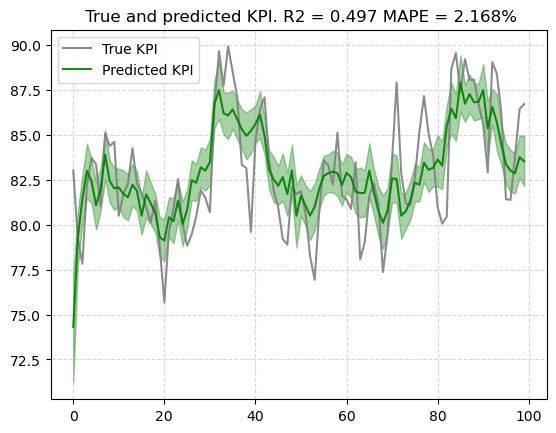

In [11]:
# https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit
from numba.core.errors import NumbaDeprecationWarning, NumbaPendingDeprecationWarning

# Generally speaking, R2 is considered good if it is more than 0.8. Also, for MAPE, the goal is for it to be 20% or below.
# MAPE or median APE instead of the R-squared metric, as those are more interpretable from a business perspective and less influenced by outliers.
plot.plot_model_fit(media_mix_model=mmm, target_scaler=target_scaler)

In [12]:
# Predictions on test set
prediction = mmm.predict(
    media=media_data_test,
    extra_features=extra_features_test,
    target_scaler=target_scaler
)

In [13]:
mmm.print_summary()
# The rule of thumb is that r_hat values for all parameters are less than 1.1.


                                 mean       std    median      5.0%     95.0%     n_eff     r_hat
ad_effect_retention_rate[0]      0.47      0.29      0.47      0.00      0.89   1872.28      1.00
ad_effect_retention_rate[1]      0.34      0.24      0.29      0.00      0.70   1056.92      1.00
ad_effect_retention_rate[2]      0.28      0.19      0.26      0.00      0.54   1782.54      1.00
     coef_extra_features[0]      0.03      0.02      0.03      0.00      0.06   1697.45      1.00
              coef_media[0]      0.01      0.02      0.01      0.00      0.03   1326.44      1.00
              coef_media[1]      0.10      0.06      0.10      0.00      0.17    765.07      1.00
              coef_media[2]      0.11      0.05      0.11      0.03      0.19    898.58      1.00
              coef_trend[0]      0.00      0.00      0.00     -0.00      0.00   1987.80      1.00
                 expo_trend      0.72      0.17      0.67      0.50      0.99    777.66      1.00
                exp

The posterior distributions below are KDE plots for each channel representing the probability density of the channel's coefficient. The x-axis is the estimated coefficient, the y-axis is how confident the model is that the x-axis value is the right value for the media effect. High numbers mean the channel influenced the revenue more. But it does not factor in ROI, as the channel's cost could be high despite it's impact. The mean is the most likely value of the parameter.

In general multiple peaks like this (bimodality or multi-modality) means there are multiple possible solutions that are all consistent with the data. It can be a sign of multicollinearity between some of your features. However, the peaks in your distributions don't look that large to me compared to the overall shape / width of the posterior distributions. One (speculative) idea I have would be that you might have a few widely-spaced values either for the data in these features or for your target variable, which could maybe produce a posterior distribution that looks like this. [source](https://github.com/google/lightweight_mmm/discussions/97)

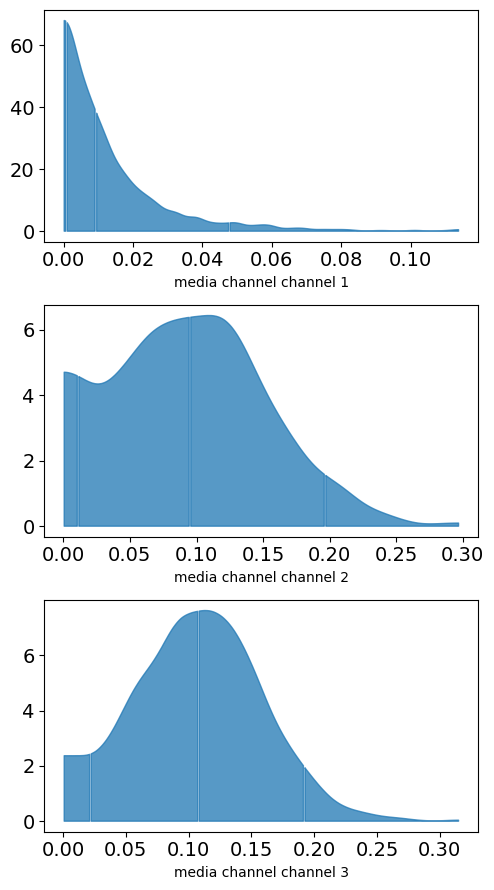

In [14]:
channel_names = ['channel 1', 'channel 2', 'channel 3']

#     plot.plot_media_channel_posteriors(media_mix_model=mmm, channel_names=channel_names)
plot.plot_media_channel_posteriors(media_mix_model=mmm, channel_names=channel_names)

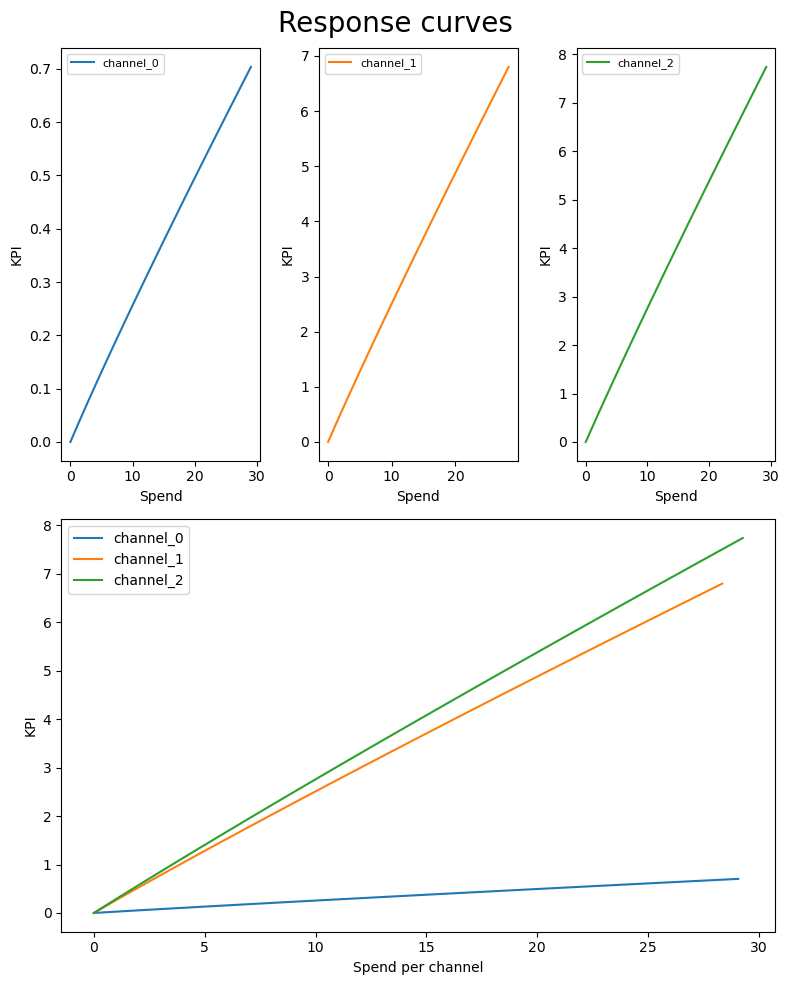

In [15]:
# Response curves measure how each media channel behaves individually as we invest more in it.
plot.plot_response_curves(media_mix_model=mmm, media_scaler=media_scaler, target_scaler=target_scaler)

In [16]:
# media_effect_hat is the media effectiveness estimation and roi_hat is the ROI estimation
# roi_hat: The return on investment of each channel calculated as its contribution divided by the cost.

# If data was scaled prior to training then the target and costs scalers need
# to be passed to this function to correctly calculate media contribution
# percentage and ROI in the unscaled space.

media_effect_hat, roi_hat = mmm.get_posterior_metrics(cost_scaler=cost_scaler, target_scaler=target_scaler)

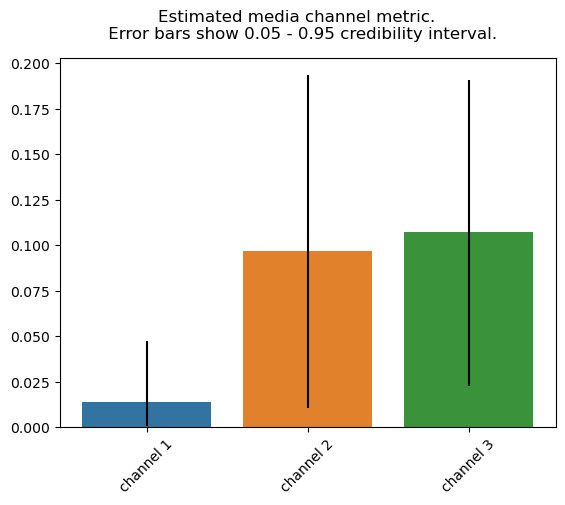

In [17]:
# This plot takes into account not only the media effect but how much it costs to get this effect. 

channel_names = ['channel 1', 'channel 2', 'channel 3']
plot.plot_bars_media_metrics(metric=media_effect_hat, channel_names=channel_names)

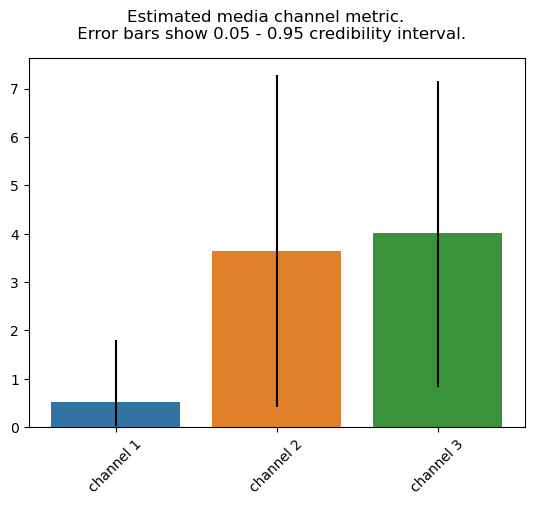

In [18]:
plot.plot_bars_media_metrics(metric=roi_hat, channel_names=channel_names)

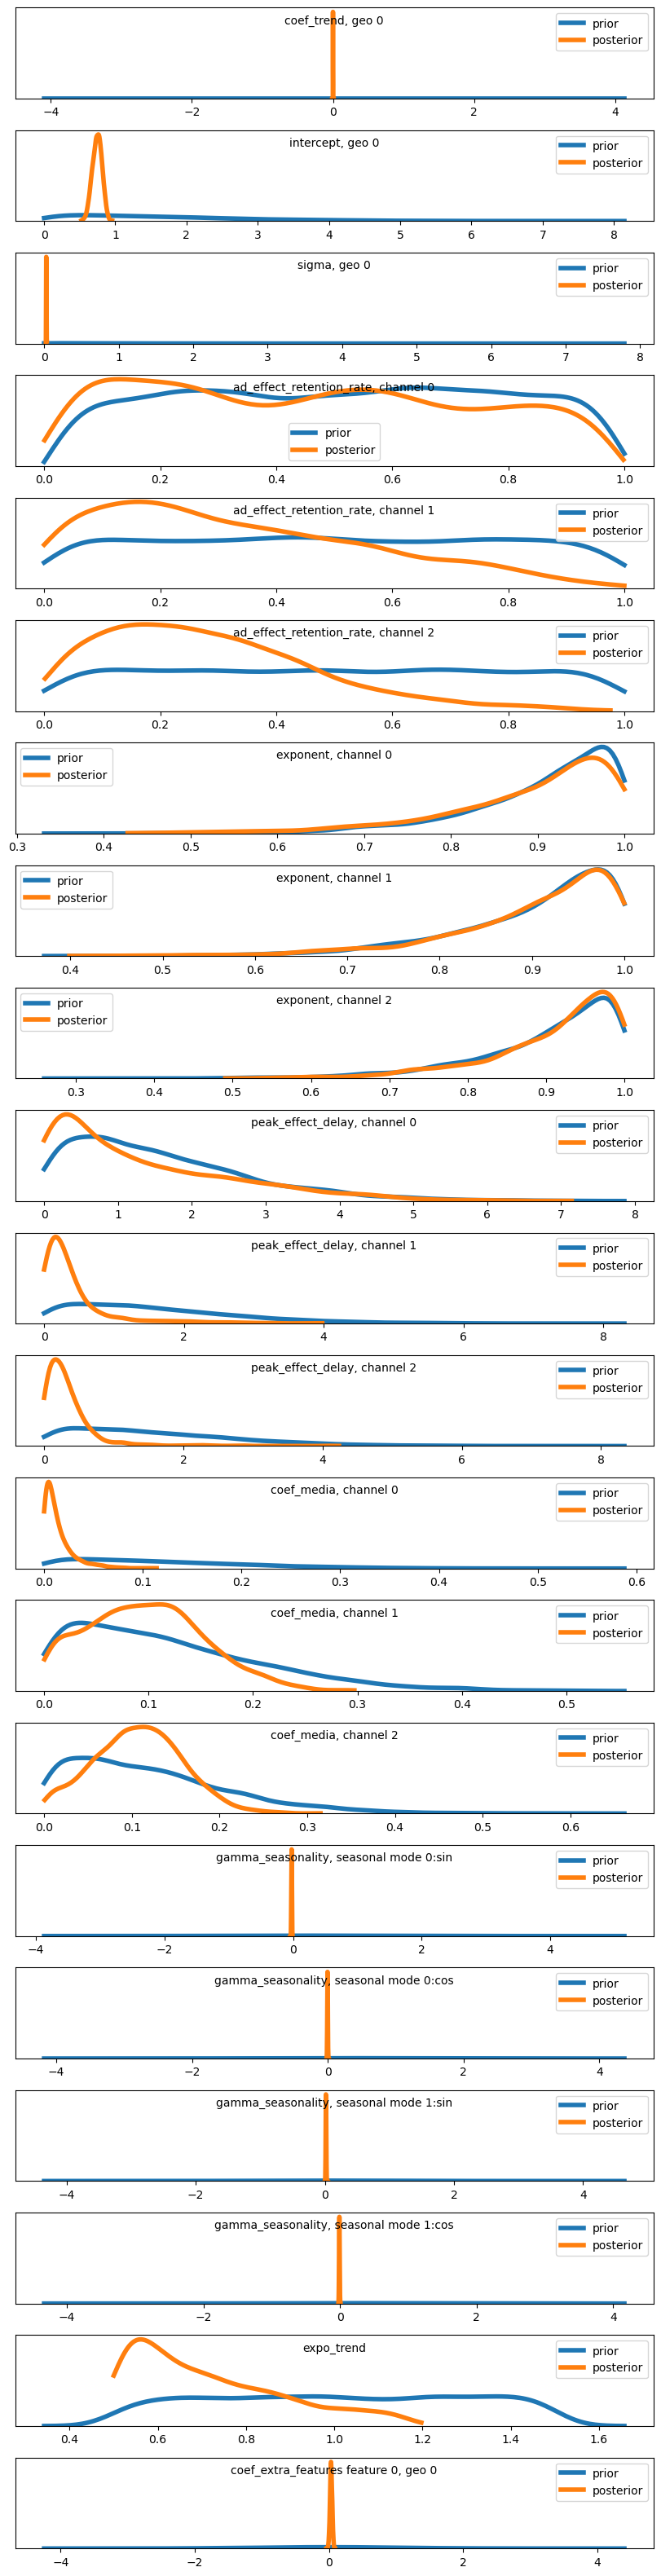

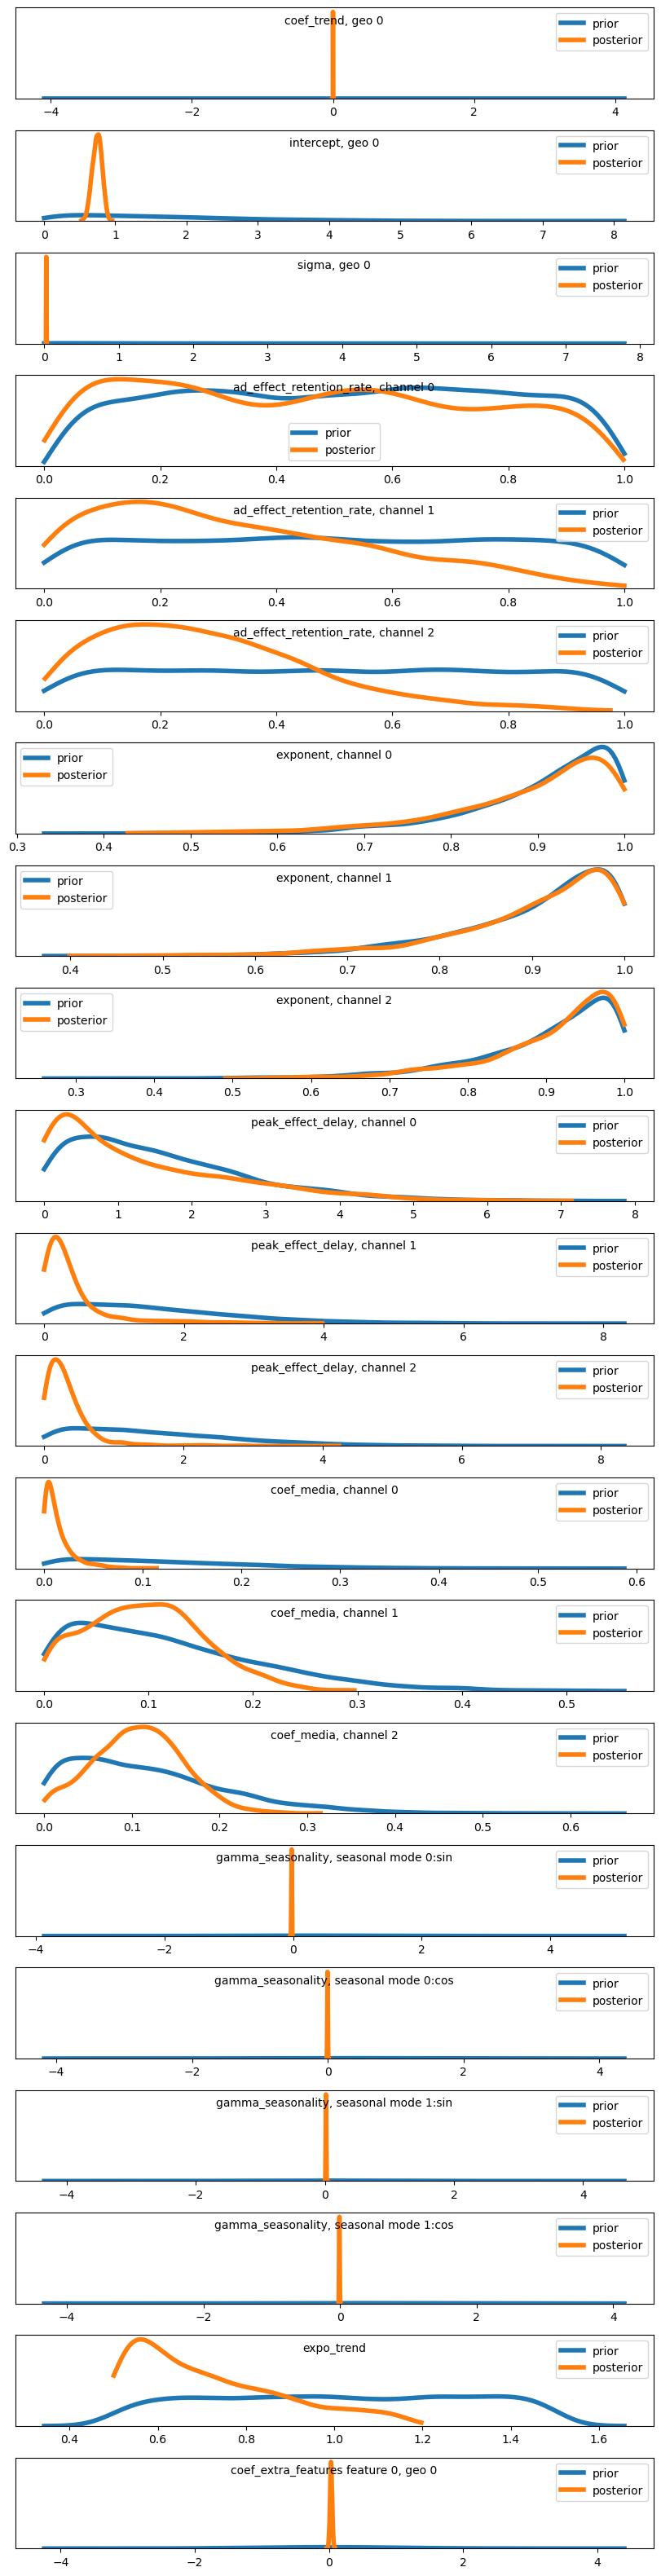

In [19]:
plot.plot_prior_and_posterior(media_mix_model=mmm)

# ad_effective_retention_rate – Retention rate of the advertisement effect. Default is 0.5.
# peak_effect_delay – Delay of the peak effect in the carryover function. Default is 1.
# gamma_seasonality – Factor to multiply to each degree calculation. Shape must be aligned with the number of degrees.

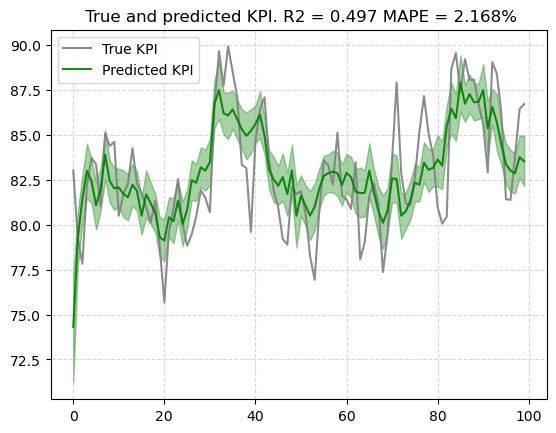

In [20]:
plot.plot_model_fit(mmm, target_scaler=target_scaler)

In [21]:
media_contribution, roi_hat = mmm.get_posterior_metrics(target_scaler=target_scaler, cost_scaler=cost_scaler)

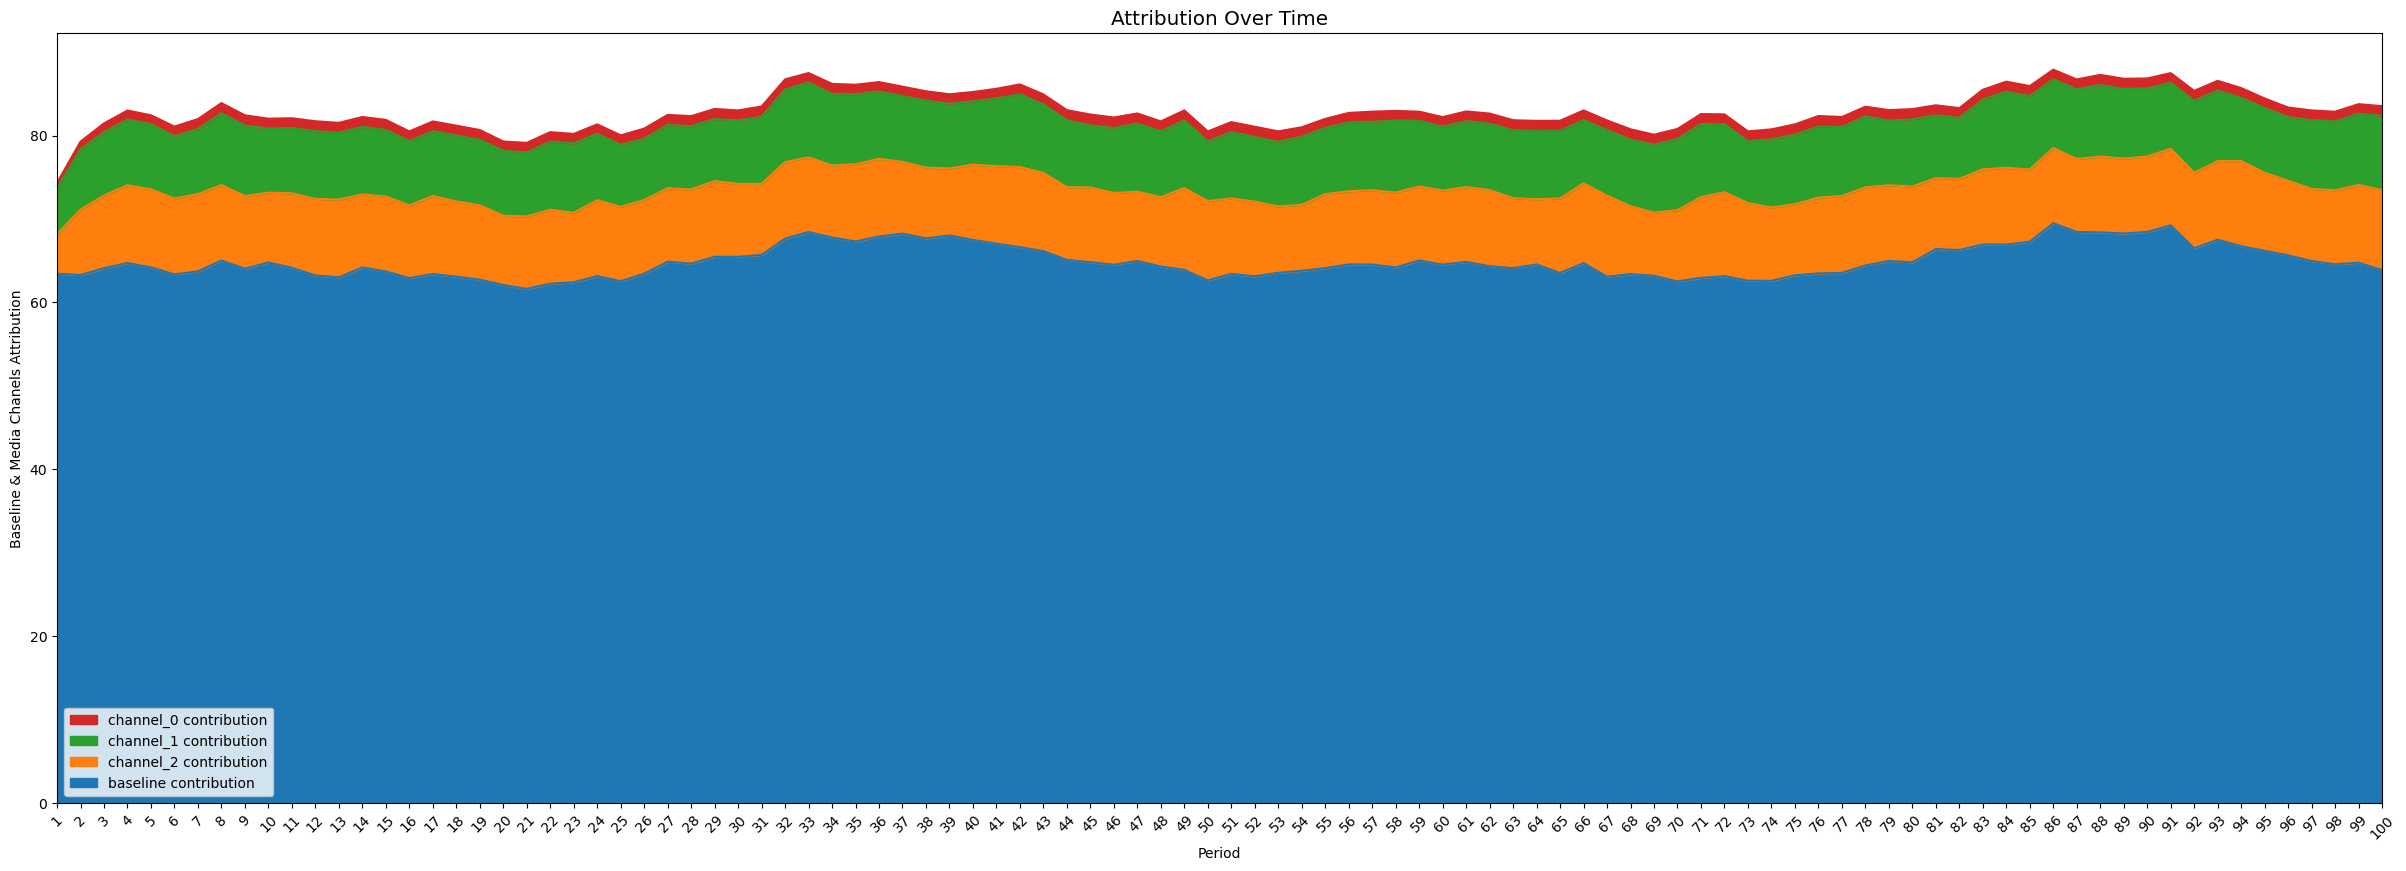

In [22]:
plot.plot_media_baseline_contribution_area_plot(media_mix_model=mmm,
                                                target_scaler=target_scaler,
                                                fig_size=(30,10))

# What can I do if the baseline is too low and total media contribution is too high?
  # You can try various things:
    # You can include non-media variables.
    # You can lower the prior for the beta (in front of the transformed media).
    # You can set a bigger prior for the intercept.

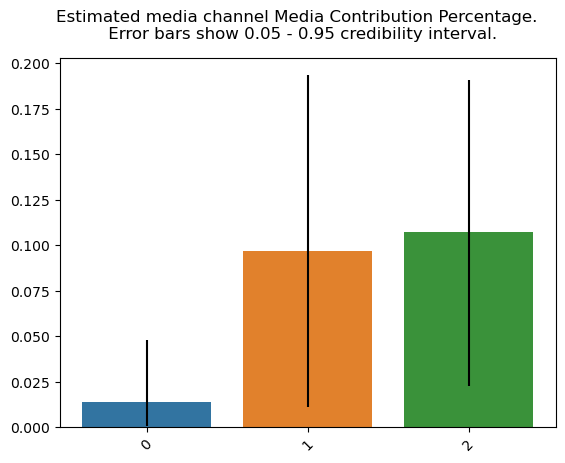

In [23]:
plot.plot_bars_media_metrics(metric=media_contribution, metric_name="Media Contribution Percentage")

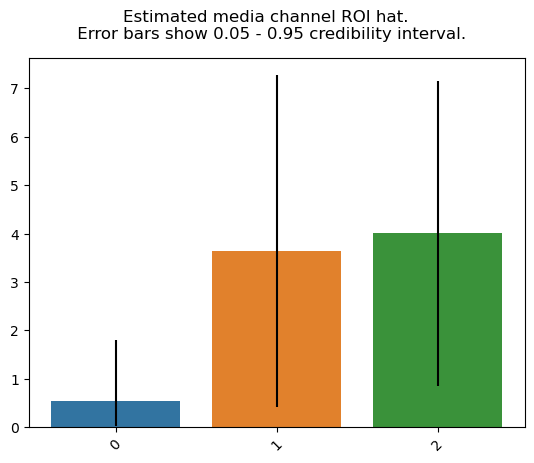

In [24]:
plot.plot_bars_media_metrics(metric=roi_hat, metric_name="ROI hat")

In [25]:
# Optimization

prices = jnp.ones(mmm.n_media_channels)

n_time_periods = 10
budget = jnp.sum(jnp.dot(prices, media_data.mean(axis=0)))* n_time_periods

In [26]:
# Run optimization with the parameters of choice.
solution, kpi_without_optim, previous_media_allocation = optimize_media.find_optimal_budgets(
    n_time_periods=n_time_periods,
    media_mix_model=mmm,
    extra_features=extra_features_scaler.transform(extra_features_test)[:n_time_periods],
    budget=budget,
    prices=prices,
    media_scaler=media_scaler,
    target_scaler=target_scaler,
    seed=seed)

Optimization terminated successfully    (Exit mode 0)
            Current function value: -838.0900068036151
            Iterations: 12
            Function evaluations: 84
            Gradient evaluations: 12


In [27]:
# Obtain the optimal weekly allocation.
optimal_buget_allocation = prices * solution.x
optimal_buget_allocation

# similar renormalization to get previous budget allocation
previous_budget_allocation = prices * previous_media_allocation
previous_budget_allocation

# Both these values should be very close in order to compare KPI
print(budget, optimal_buget_allocation.sum())

# Both numbers should be almost equal
print(budget, jnp.sum(solution.x * prices))

600.98334 600.98334
600.98334 600.98334


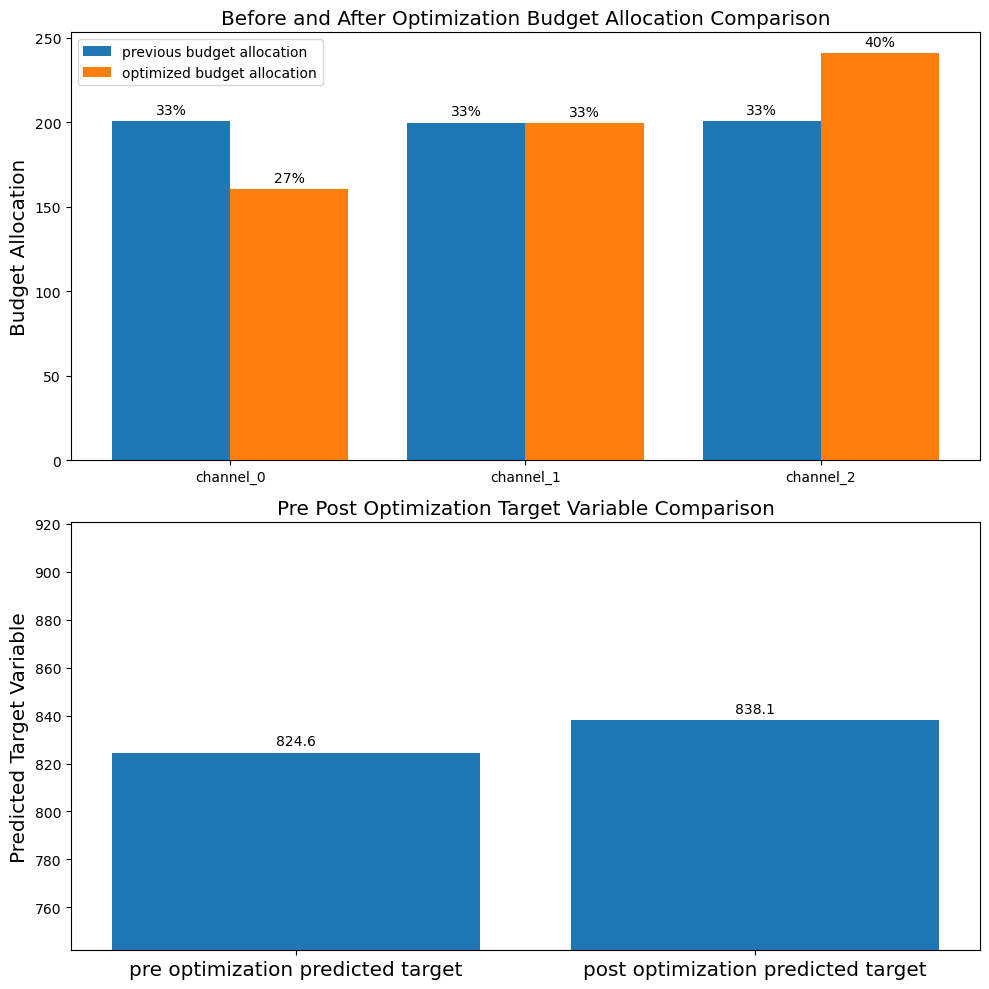

In [28]:
# Plot out pre post optimization budget allocation and predicted target variable comparison.
plot.plot_pre_post_budget_allocation_comparison(media_mix_model=mmm, 
                                                kpi_with_optim=solution['fun'], 
                                                kpi_without_optim=kpi_without_optim,
                                                optimal_buget_allocation=optimal_buget_allocation, 
                                                previous_budget_allocation=previous_budget_allocation, 
                                                figure_size=(10,10))

In [29]:
# We can use the utilities for saving models to disk.
file_path = "media_mix_model.pkl"
utils.save_model(media_mix_model=mmm, file_path=file_path)

# Once saved one can load the models.
# loaded_mmm = utils.load_model(file_path=file_path)
# loaded_mmm.trace["coef_media"].shape # Example of accessing any of the model values.

## Incorporating lift results into model

A reasonable starting point would be to keep the prior on the channel coefficient as a half-normal, but change the scale of that half-normal so that its mean is the same as the result of your experiment result.

To do this, you first have to convert your ROI for a given channel as measured from your experiment into a beta for that channel: ROI = beta x F(impressions) / spend, where F is your media transformation for that channel (you'll have to assume values here for the hill and adstock parameters). Once you have your point estimate for beta, you can solve for the corresponding scale parameter for the half-normal as: scale = beta x sqrt( pi / 2). More detail [here](https://github.com/google/lightweight_mmm/discussions/87).